# Análisis, Limpieza y Modelado

## Análisis
**Ficheros json analizados:**
> locales \
> actividades \
> licencias \
> terrazas 

**Nota:** En lugar de utilizar la librería `pandas` para la exploración y limpieza de los datos, prefiero utilizar la librería `duckdb`

**Ventajas DuckDB:** 
- SQL nativo
- Soporta consultas directas sobre ficheros externos `select...from csv|json|parquet`
- Vectoriza todas sus consultas con lo que consigue una velocidad de respuesta superior a pandas

In [158]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyproj import Transformer

#### Settings

In [2]:
pd.set_option('display.max_columns', None) 

### Volumetría:

**Definir de variables:**

In [3]:
data_dir = "../data"
data_raw_dir = f"{data_dir}/raw"
data_processed_dir = f"{data_dir}/processed"

In [4]:
ficheros_json = {
    "locales": f"{data_raw_dir}/locales202312.json",
    "actividades": f"{data_raw_dir}/actividadeconomica202312.json",
    "licencias": f"{data_raw_dir}/licencias202312.json",
    "terrazas": f"{data_raw_dir}/terrazas202312.json",
    "listings": f"{data_raw_dir}/airbnb_listings.json",
}

**Obtener numero de registros de los ficheros json. Guardarlos en una lista**

In [5]:
volumetria = []
for entidad, ruta in ficheros_json.items():
    sql_count = f"""SELECT count(1) FROM '{ruta}'"""
    resultado = duckdb.sql(sql_count).fetchone()[0] # type: ignore
    volumetria.append({
        "entidad": entidad,
        "registros": resultado
    })

**Generar gráfico de la volumetría de los ficheros json**

In [6]:
df_plot = pd.DataFrame(volumetria).sort_values(by='registros', ascending=False)

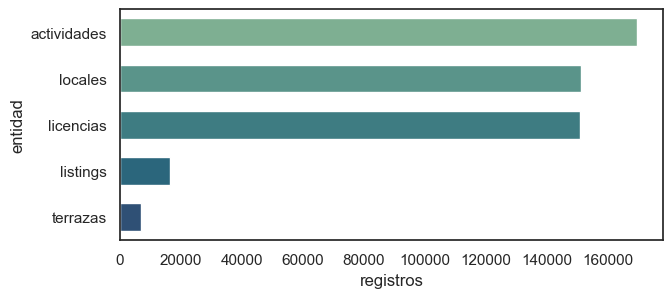

In [7]:
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(7, 3), dpi=100)
ax = sns.barplot(
    data=df_plot, 
    x='registros', 
    y='entidad', 
    hue='entidad', 
    palette='crest', 
    legend=False,
    width=0.6,
    ax=ax
)

In [8]:
volumetria

[{'entidad': 'locales', 'registros': 151162},
 {'entidad': 'actividades', 'registros': 169559},
 {'entidad': 'licencias', 'registros': 150829},
 {'entidad': 'terrazas', 'registros': 6788},
 {'entidad': 'listings', 'registros': 16313}]

# Limpieza

### Materializar ficheros como tablas (in memory)

In [9]:
con = duckdb.connect()
con.execute("PRAGMA enable_profiling;")

### Schema Definitions

In [10]:
con.execute("create schema if not exists landing")
con.execute("create schema if not exists raw")
con.execute("create schema if not exists silver")
con.execute("create schema if not exists gold")

In [11]:
landing_schema = "landing"
raw_schema = "raw"
silver_schema = "silver"    
gold_schema = "gold"

### Landing Layer

In [12]:
con.execute(f"CREATE OR REPLACE TABLE {landing_schema}.locales AS SELECT * FROM read_json_auto('{data_raw_dir}/locales202312.json')")

In [13]:
con.execute(f"CREATE OR REPLACE TABLE {landing_schema}.actividades AS SELECT * FROM read_json_auto('{data_raw_dir}/actividadeconomica202312.json')")

In [14]:
con.execute(f"CREATE OR REPLACE TABLE {landing_schema}.licencias AS SELECT * FROM read_json_auto('{data_raw_dir}/licencias202312.json')")

In [15]:
con.execute(f"CREATE OR REPLACE TABLE {landing_schema}.terrazas AS SELECT * FROM read_json_auto('{data_raw_dir}/terrazas202312.json')")

### Raw Layer
> Se quitan espacios de los campos que son string \
> Convierte vacío a NULL \
> Todos los campos se ponen a minusculas

In [16]:
def clean_table(con, origin_schema, destiny_schema, table_name):
    query = f"""
    SELECT 
        'CREATE OR REPLACE TABLE {destiny_schema}.{table_name} AS SELECT ' ||
        string_agg(
            CASE 
                WHEN data_type = 'VARCHAR' 
                THEN 'NULLIF(TRIM(' || column_name || '), '''') AS ' || lower(column_name)
                ELSE column_name || ' AS ' || lower(column_name)
            END,
            ', '
            ORDER BY ordinal_position
        )
        || ' FROM {origin_schema}.{table_name};'
    FROM information_schema.columns
    WHERE table_name = '{table_name}';
    """
    
    generated_sql = con.execute(query).fetchone()[0]
    con.execute(generated_sql)

In [17]:
clean_table(con, landing_schema, raw_schema, "locales")
clean_table(con, landing_schema, raw_schema, "actividades") # process_table
clean_table(con, landing_schema, raw_schema, "licencias") 
clean_table(con, landing_schema, raw_schema, "terrazas") 

### Python. Locales. Convertir UTM → WGS84 (World Geodetic System 1984)

**Extraer coordenadas UTM**

In [198]:
df_locales = con.execute(f"""
SELECT 
    id_local,
    coordenada_x_local,
    coordenada_y_local
FROM {raw_schema}.locales
WHERE coordenada_x_local != 0 OR coordenada_y_local != 0
""").fetchdf()

**Transformación**

In [199]:
transformer = Transformer.from_crs("EPSG:25830", "EPSG:4326", always_xy=True)

lon, lat = transformer.transform(
    df_locales["coordenada_x_local"].values,
    df_locales["coordenada_y_local"].values
)

df_locales["longitud"] = lon
df_locales["latitud"] = lat

**Crear GeoJSON**

In [200]:
df_locales["location"] = df_locales.apply(
    lambda row: {
        "type": "Point",
        "coordinates": [row["longitud"], row["latitud"]]
    },
    axis=1
)

**Registrar en DuckDB**

In [202]:
con.register("locales_geo_tmp", df_locales)

### Silver Layer

**`Tabla` locales:**
> PK: *id_local* \
> Quitar registros incoherentes por PK -> null, 0 \
> Quitar "duplicados" por PK -> No existen \
> Añadir campo de geolocalización WGS84

In [204]:
con.execute(f"CREATE OR REPLACE TABLE {silver_schema}.locales AS \
            SELECT \
                src.*, \
                geo.location \
            FROM {raw_schema}.locales src \
            LEFT JOIN locales_geo_tmp geo \
            ON src.id_local = geo.id_local \
            where ifnull(src.id_local, 0) != 0 \
            qualify row_number() over (partition by src.id_local order by src.fx_carga desc) = 1")

**`Tabla` actividades:**
> PK: *id_local*, *id_epigrafe* \
> FK: *id_local* \
> Quitar Hijas sin Padres -> `id_local` en actividades que no existen en locales \
> Quitar registros incoherentes por PK -> id_epigrafe = '-1' \
> Quitar "duplicados" por PK -> No existen

In [43]:
con.execute(f"CREATE OR REPLACE TABLE {silver_schema}.actividades AS \
            SELECT * \
            FROM {raw_schema}.actividades src \
            where ifnull(src.id_epigrafe, '-1') != '-1' \
            and exists (select 1 from {silver_schema}.locales where src.id_local = id_local) \
            qualify row_number() over (partition by src.id_local, src.id_epigrafe order by src.fx_carga desc) = 1")

**`Tabla` licencias:**
> PK: *id_local*, *ref_licencia* \
> FK: *id_local* \
> Quitar Hijas sin Padres -> `id_local` en licencias que no existen en locales \
> Quitar registros incoherentes por PK -> ref_licencia = '-1' \
> Quitar "duplicados" por PK -> Existen 8 registros

In [44]:
con.execute(f"CREATE OR REPLACE TABLE {silver_schema}.licencias AS \
            SELECT * \
            FROM {raw_schema}.licencias src \
            where ifnull(src.ref_licencia, '-1') != '-1' \
            and exists (select 1 from {silver_schema}.locales where src.id_local = id_local) \
            qualify row_number() over (partition by src.id_local, src.ref_licencia order by src.fecha_dec_lic desc) = 1")

**`Tabla` terrazas:**
> PK: *id_terraza* \
> FK: *id_local* \
> Quitar Hijas sin Padres -> `id_local` en terrazas que no existen en locales \
> Quitar registros incoherentes por PK -> null, 0 \
> Quitar "duplicados" por PK -> No existen

In [45]:
con.execute(f"CREATE OR REPLACE TABLE {silver_schema}.terrazas AS \
            SELECT * \
            FROM {raw_schema}.terrazas src \
            where ifnull(src.id_terraza, 0) != 0 \
            and exists (select 1 from {silver_schema}.locales where src.id_local = id_local) \
            qualify row_number() over (partition by src.id_terraza order by src.fx_carga desc) = 1")

# Gold Layer

In [205]:
con.execute(f"CREATE OR REPLACE TABLE {gold_schema}.locales AS \
SELECT \
    l.*, \
    list(a) FILTER (WHERE a IS NOT NULL) AS actividades, \
    list(li) FILTER (WHERE li IS NOT NULL) AS licencias, \
    any_value(t) FILTER (WHERE t IS NOT NULL) AS terraza \
FROM {silver_schema}.locales l \
LEFT JOIN {silver_schema}.actividades a \
ON l.id_local = a.id_local \
LEFT JOIN {silver_schema}.licencias li \
ON l.id_local = li.id_local \
LEFT JOIN {silver_schema}.terrazas t \
ON l.id_local = t.id_local \
GROUP BY ALL \
")

### Tomando solo el 10% de los datos de locales

In [213]:
con.execute(f"CREATE OR REPLACE TABLE locales_sample AS \
            SELECT * \
            FROM {gold_schema}.locales \
            WHERE location IS NOT NULL \
            USING SAMPLE 10% (bernoulli)")

In [221]:
con.execute(f"""
COPY locales_sample
TO 'locales_mongo_ready2.json'
(FORMAT JSON, ARRAY TRUE);
""")

In [217]:
con.execute(f"select location, location.coordinates from locales_geo_tmp where id_local = 270555238").df()

,location,coordinates


In [209]:
con.execute(f"select location, coordenada_x_local, coordenada_y_local from {silver_schema}.locales where id_local = 270555238").fetchall()

[(None, 0.0, 0.0)]

In [180]:
con.execute(f"select id_local from {gold_schema}.locales order by id_local").df().head(10)

,id_local
0,10000003
1,10000004
2,10000013
3,10000044
4,10000052
5,10000071
6,10000093
7,10000097
8,10000102
9,10000105


In [218]:
con.execute(f"select substr(id_local::VARCHAR, 1, 4), count(*) as count from locales_sample group by substr(id_local::VARCHAR, 1, 4) order by 1").df().head(30)

,"substr(CAST(id_local AS VARCHAR), 1, 4)",count
0,1000,119
1,1100,61
2,1200,23
3,1300,41
4,1400,11
5,1500,66
6,1600,46
7,1700,70
8,1800,28
9,1900,15


In [ ]:
con.execute(f"SELECT to_json(struct_pack(COLUMNS(*))) AS s FROM {gold_schema}.locales limit 10").df()

In [ ]:
con.execute(f"""
COPY (
    SELECT
        struct_pack(COLUMNS(*)) 
    FROM {gold_schema}.locales
)
TO 'locales.json'
(FORMAT JSON, ARRAY TRUE);
""")

In [175]:
con.execute(f"select count(1) from {silver_schema}.locales").df()

,count(1)
0,151162


In [177]:
con.execute(f"select count(1) from {gold_schema}.locales").df()

,count(1)
0,151162


In [139]:
con.execute(f"select count(distinct(COLUMNS(*))) from {gold_schema}.locales loc").df()

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,cod_postal,hora_apertura1,hora_cierre2,fx_carga,fx_datos_ini,fx_datos_fin,hora_cierre1,hora_apertura2,coordenada_x_agrupacion,coordenada_y_agrupacion,actividades,licencias,terraza
0,151162,21,21,131,131,9,2418,222,59413,77828,3,3,7,7,6393,25,6161,65696,1,2,681,29,286,6555,25,6303,72142,1,2,691,30,426,417,12,12,20,3467,79735,55,63,34,2,1,1,56,37,365,364,111873,74153,6768


In [141]:
con.execute(f"select id_local, terraza, actividades, licencias from {gold_schema}.locales").df().head(10)

,id_local,terraza,actividades,licencias
0,270270768,"{'id_terraza': 5863, 'id_local': 270270768, 'i...","[{'id_local': 270270768, 'id_distrito_local': ...","[{'id_local': 270270768, 'id_distrito_local': ..."
1,270526771,"{'id_terraza': 19325, 'id_local': 270526771, '...","[{'id_local': 270526771, 'id_distrito_local': ...","[{'id_local': 270526771, 'id_distrito_local': ..."
2,270168776,"{'id_terraza': None, 'id_local': None, 'id_dis...","[{'id_local': 270168776, 'id_distrito_local': ...","[{'id_local': 270168776, 'id_distrito_local': ..."
3,270171989,"{'id_terraza': None, 'id_local': None, 'id_dis...","[{'id_local': 270171989, 'id_distrito_local': ...","[{'id_local': 270171989, 'id_distrito_local': ..."
4,270184042,"{'id_terraza': None, 'id_local': None, 'id_dis...","[{'id_local': 270184042, 'id_distrito_local': ...","[{'id_local': 270184042, 'id_distrito_local': ..."
5,270213909,"{'id_terraza': None, 'id_local': None, 'id_dis...","[{'id_local': 270213909, 'id_distrito_local': ...","[{'id_local': 270213909, 'id_distrito_local': ..."
6,270213958,"{'id_terraza': None, 'id_local': None, 'id_dis...","[{'id_local': 270213958, 'id_distrito_local': ...","[{'id_local': 270213958, 'id_distrito_local': ..."
7,270240912,"{'id_terraza': None, 'id_local': None, 'id_dis...","[{'id_local': 270240912, 'id_distrito_local': ...","[{'id_local': 270240912, 'id_distrito_local': ..."
8,270278200,"{'id_terraza': None, 'id_local': None, 'id_dis...","[{'id_local': 270278200, 'id_distrito_local': ...","[{'id_local': 270278200, 'id_distrito_local': ..."
9,270278388,"{'id_terraza': None, 'id_local': None, 'id_dis...","[{'id_local': 270278388, 'id_distrito_local': ...","[{'id_local': 270278388, 'id_distrito_local': ..."


In [110]:
con.execute(f"select id_local, actividades, licencias, terraza from {gold_schema}.locales").df().head(5)

,id_local,actividades,licencias,terraza
0,270305564,"[{'id_local': 270305564, 'id_distrito_local': ...","[{'id_local': 270305564, 'id_distrito_local': ...","[{'id_terraza': 17460, 'id_local': 270305564, ..."
1,270174394,"[{'id_local': 270174394, 'id_distrito_local': ...","[{'id_local': 270174394, 'id_distrito_local': ...","[{'id_terraza': None, 'id_local': None, 'id_di..."
2,270182349,"[{'id_local': 270182349, 'id_distrito_local': ...","[{'id_local': 270182349, 'id_distrito_local': ...","[{'id_terraza': None, 'id_local': None, 'id_di..."
3,270225911,"[{'id_local': 270225911, 'id_distrito_local': ...","[{'id_local': 270225911, 'id_distrito_local': ...","[{'id_terraza': None, 'id_local': None, 'id_di..."
4,270235496,"[{'id_local': 270235496, 'id_distrito_local': ...","[{'id_local': 270235496, 'id_distrito_local': ...","[{'id_terraza': None, 'id_local': None, 'id_di..."


In [109]:
con.execute(f"select * from {gold_schema}.locales").df().head(5)

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,cod_postal,hora_apertura1,hora_cierre2,fx_carga,fx_datos_ini,fx_datos_fin,hora_cierre1,hora_apertura2,coordenada_x_agrupacion,coordenada_y_agrupacion,actividades,licencias,terraza
0,270305564,5,CHAMARTIN,501,EL VISO,1,5005,5,441571.60,4478132.52,1,Puerta Calle,1,Abierto,203700,AVENIDA,CONCHA ESPINA,11020912,1,NUM,6,NaN,30,203700,AVENIDA,CONCHA ESPINA,11020912,1,NUM,6,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,02,TACO BELL,28036,10:00:00,<NA>,2023-12-08T07:01:00,2023-12-01,2023-12-01,02:00:00,<NA>,NaN,NaN,"[{'id_local': 270305564, 'id_distrito_local': ...","[{'id_local': 270305564, 'id_distrito_local': ...","[{'id_terraza': 17460, 'id_local': 270305564, ..."
1,270174394,15,CIUDAD LINEAL,1505,SAN PASCUAL,5,15141,141,444695.58,4477117.48,1,Puerta Calle,1,Abierto,71300,CALLE,ARISTOTELES,11111063,1,NUM,6,NaN,10,71300,CALLE,ARISTOTELES,11111063,1,NUM,6,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,AB,DORADA,28027,<NA>,<NA>,2023-12-08T07:01:00,2023-12-01,2023-12-01,<NA>,<NA>,NaN,NaN,"[{'id_local': 270174394, 'id_distrito_local': ...","[{'id_local': 270174394, 'id_distrito_local': ...","[{'id_terraza': None, 'id_local': None, 'id_di..."
2,270182349,17,VILLAVERDE,1704,LOS ROSALES,4,17050,50,441301.54,4467498.51,1,Puerta Calle,1,Abierto,786850,CALLE,VILLAJOYOSA,11126753,1,NUM,78,NaN,10,786850,CALLE,VILLAJOYOSA,11126753,1,NUM,78,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,ALIMENTACIÓN Y BAZAR,28041,<NA>,<NA>,2023-12-08T07:01:00,2023-12-01,2023-12-01,<NA>,<NA>,NaN,NaN,"[{'id_local': 270182349, 'id_distrito_local': ...","[{'id_local': 270182349, 'id_distrito_local': ...","[{'id_terraza': None, 'id_local': None, 'id_di..."
3,270225911,15,CIUDAD LINEAL,1502,PUEBLO NUEVO,2,15057,57,445849.57,4475566.46,1,Puerta Calle,1,Abierto,344700,CALLE,GREGORIO DONAS,11106525,1,NUM,4,NaN,10,344700,CALLE,GREGORIO DONAS,11106525,1,NUM,4,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,A,MOTORCLEAN,28017,<NA>,<NA>,2023-12-08T07:01:00,2023-12-01,2023-12-01,<NA>,<NA>,NaN,NaN,"[{'id_local': 270225911, 'id_distrito_local': ...","[{'id_local': 270225911, 'id_distrito_local': ...","[{'id_terraza': None, 'id_local': None, 'id_di..."
4,270235496,12,USERA,1207,PRADOLONGO,7,12097,97,440066.58,4470706.52,1,Puerta Calle,1,Abierto,533600,CALLE,NICOLAS SANCHEZ,11086976,1,NUM,37,NaN,30,533600,CALLE,NICOLAS SANCHEZ,11086976,1,NUM,37,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,IZ,CAFETERÍA - PASTELERÍA,28026,08:00:00,<NA>,2023-12-08T07:01:00,2023-12-01,2023-12-01,23:00:00,<NA>,NaN,NaN,"[{'id_local': 270235496, 'id_distrito_local': ...","[{'id_local': 270235496, 'id_distrito_local': ...","[{'id_terraza': None, 'id_local': None, 'id_di..."


In [ ]:
###########################################################################

In [46]:
con.execute(f"select count(1) from {silver_schema}.actividades").df()


,count(1)
0,130267


In [47]:
con.execute(f"select count(1) from {silver_schema}.licencias").df()

,count(1)
0,150821


In [48]:
con.execute(f"select count(1) from {silver_schema}.terrazas").df()

,count(1)
0,6767


In [29]:
con.execute(f"select * from {raw_schema}.locales").df().head(5)

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_pc,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,cod_postal,hora_apertura1,hora_cierre2,fx_carga,fx_datos_ini,fx_datos_fin,hora_cierre1,hora_apertura2,coordenada_x_agrupacion,coordenada_y_agrupacion
0,20000596,2,ARGANZUELA,203,CHOPERA,3,2043,43,440788.58,4471857.52,1,Puerta Calle,1,Abierto,744250,CALLE,TOMAS BORRAS,11008969,1,NUM,12,NaN,20,744250,CALLE,TOMAS BORRAS,11008969,1,NUM,12,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,D1,LA CAÑA,28045,09:00:00,22:00:00,2023-12-08T07:01:00,2023-12-01,2023-12-01,<NA>,<NA>,NaN,NaN
1,20000605,2,ARGANZUELA,201,IMPERIAL,1,2107,107,439316.59,4472540.53,1,Puerta Calle,1,Abierto,597700,GLORIETA,PIRAMIDES,11008222,1,NUM,6,NaN,20,597700,GLORIETA,PIRAMIDES,11008222,1,NUM,6,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,CAFETERIA PIRAMIDES,28005,<NA>,<NA>,2023-12-08T07:01:00,2023-12-01,2023-12-01,<NA>,<NA>,NaN,NaN
2,20000669,2,ARGANZUELA,202,ACACIAS,2,2096,96,439770.59,4472407.53,1,Puerta Calle,1,Abierto,501150,CALLE,MELILLA,20123782,1,NUM,39,NaN,50,501150,CALLE,MELILLA,20123782,1,NUM,39,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,M1,BAR MELILLA,28005,<NA>,<NA>,2023-12-08T07:01:00,2023-12-01,2023-12-01,<NA>,<NA>,NaN,NaN
3,20000709,2,ARGANZUELA,202,ACACIAS,2,2029,29,440355.59,4472282.53,1,Puerta Calle,1,Abierto,274600,PASEO,ESPERANZA,11008673,1,NUM,45,NaN,10,274600,PASEO,ESPERANZA,11008673,1,NUM,45,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,IZ,SUPERMERCADOS SIMPLY,28005,<NA>,<NA>,2023-12-08T07:01:00,2023-12-01,2023-12-01,<NA>,<NA>,NaN,NaN
4,20000721,2,ARGANZUELA,201,IMPERIAL,1,2089,89,439312.59,4472870.53,1,Puerta Calle,1,Abierto,917,PASEO,JUAN ANTONIO VALLEJO-NAJERA BOTAS,20106307,1,NUM,54,NaN,40,917,PASEO,JUAN ANTONIO VALLEJO-NAJERA BOTAS,20106307,1,NUM,54,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,C,ARROCERIA IMPERIAL,28005,<NA>,<NA>,2023-12-08T07:01:00,2023-12-01,2023-12-01,<NA>,<NA>,NaN,NaN


In [27]:
con.execute(f"select count(1) from {raw_schema}.locales where id_local is null").df()

,count(1)
0,0


In [ ]:
con.execute(f"select id_local, count(1) from {raw_schema}.locales group by id_local having count(1) > 1").df()

,id_local,count(1)


In [30]:
con.execute(f"select id_local, coordenada_x_local, coordenada_y_local from {raw_schema}.locales").df().head(7)

,id_local,coordenada_x_local,coordenada_y_local
0,20000596,440788.58,4471857.52
1,20000605,439316.59,4472540.53
2,20000669,439770.59,4472407.53
3,20000709,440355.59,4472282.53
4,20000721,439312.59,4472870.53
5,20000729,441172.58,4471946.52
6,20000756,440659.59,4472755.52


In [41]:
con.execute(f"select location as coordenadas_listings_airbnb from '{data_raw_dir}/airbnb_listings.json'").df().head(5)

,coordenadas_listings_airbnb
0,"{'coordinates': [40.424715317537384, -3.698638..."
1,"{'coordinates': [40.413418179848634, -3.706838..."
2,"{'coordinates': [40.42492023544748, -3.7134461..."
3,"{'coordinates': [40.4034095295952, -3.74084196..."
4,"{'coordinates': [40.4234166657964, -3.71245624..."


In [35]:
con.execute(f"select location.coordinates as coordenadas_listings_airbnb from '{data_raw_dir}/airbnb_listings.json'").df().head(5)

,coordenadas_listings_airbnb
0,"[40.424715317537384, -3.6986381877058387]"
1,"[40.413418179848634, -3.706838445919361]"
2,"[40.42492023544748, -3.7134461317198415]"
3,"[40.4034095295952, -3.740841968636018]"
4,"[40.4234166657964, -3.712456247572053]"


In [169]:
con.execute(f"select id_terraza, count(1) as cantidad FROM {raw_schema}.terrazas group by id_terraza having cantidad > 1").df().head(4)

,id_terraza,cantidad


In [173]:
con.execute(f"select * FROM {raw_schema}.terrazas").df().head(4)

,id_terraza,id_terraza_1,id_local,id_local_1,id_distrito_local,id_distrito_local_1,desc_distrito_local,desc_distrito_local_1,id_barrio_local,id_barrio_local_1,desc_barrio_local,desc_barrio_local_1,id_ndp_edificio,id_ndp_edificio_1,id_clase_ndp_edificio,id_clase_ndp_edificio_1,id_vial_edificio,id_vial_edificio_1,clase_vial_edificio,clase_vial_edificio_1,desc_vial_edificio,desc_vial_edificio_1,nom_edificio,nom_edificio_1,num_edificio,num_edificio_1,cod_postal,cod_postal_1,coordenada_x_local,coordenada_x_local_1,coordenada_y_local,coordenada_y_local_1,id_tipo_acceso_local,id_tipo_acceso_local_1,desc_tipo_acceso_local,desc_tipo_acceso_local_1,id_situacion_local,id_situacion_local_1,desc_situacion_local,desc_situacion_local_1,secuencial_local_pc,secuencial_local_pc_1,escalera,escalera_1,id_planta_agrupado,id_planta_agrupado_1,id_local_agrupado,id_local_agrupado_1,rotulo,rotulo_1,id_periodo_terraza,id_periodo_terraza_1,desc_periodo_terraza,desc_periodo_terraza_1,id_situacion_terraza,id_situacion_terraza_1,desc_situacion_terraza,desc_situacion_terraza_1,superficie_es,superficie_es_1,superficie_ra,superficie_ra_1,fecha_confir_ult_decreto_resol,fecha_confir_ult_decreto_resol_1,id_ndp_terraza,id_ndp_terraza_1,id_clase_ndp_terraza,id_clase_ndp_terraza_1,id_vial,id_vial_1,desc_clase,desc_clase_1,desc_nombre,desc_nombre_1,nom_terraza,nom_terraza_1,num_terraza,num_terraza_1,cal_terraza,cal_terraza_1,desc_ubicacion_terraza,desc_ubicacion_terraza_1,hora_ini_lj_es,hora_ini_lj_es_1,hora_fin_lj_es,hora_fin_lj_es_1,hora_ini_lj_ra,hora_ini_lj_ra_1,hora_fin_lj_ra,hora_fin_lj_ra_1,hora_ini_vs_es,hora_ini_vs_es_1,hora_fin_vs_es,hora_fin_vs_es_1,hora_ini_vs_ra,hora_ini_vs_ra_1,hora_fin_vs_ra,hora_fin_vs_ra_1,mesas_aux_es,mesas_aux_es_1,mesas_aux_ra,mesas_aux_ra_1,mesas_es,mesas_es_1,mesas_ra,mesas_ra_1,sillas_es,sillas_es_1,sillas_ra,sillas_ra_1,cal_edificio,cal_edificio_1,fx_carga,fx_carga_1,fx_datos_ini,fx_datos_ini_1,fx_datos_fin,fx_datos_fin_1,coordenada_x_agrupacion,coordenada_x_agrupacion_1,coordenada_y_agrupacion,coordenada_y_agrupacion_1
0,33,33,270403150,270403150,4,4,SALAMANCA,SALAMANCA,404,404,GUINDALERA,GUINDALERA,11018870,11018870,1,1,42500,42500,AVENIDA,AVENIDA,AMERICA,AMERICA,NUM,NUM,2,2,28028,28028,442586.58,442586.58,4476524.51,4476524.51,1,1,Puerta Calle,Puerta Calle,1,1,Abierto,Abierto,30,30,NaN,NaN,PB,PB,01,01,VIPS,VIPS,1,1,Anual,Anual,1,1,Abierta,Abierta,21.06,21.06,16.20,16.20,04/04/2014,04/04/2014,11018870,11018870,1,1,42500,42500,AVENIDA,AVENIDA,AMERICA,AMERICA,NUM,NUM,2,2,NaN,NaN,Acera,Acera,10:00:00,10:00:00,01:00:00,01:00:00,10:00:00,10:00:00,00:00:00,00:00:00,10:00:00,10:00:00,02:30:00,02:30:00,10:00:00,10:00:00,00:00:00,00:00:00,0,0,0,0,9,9,9,9,27,27,27,27,NaN,NaN,2023-12-08T07:00:49,2023-12-08T07:00:49,2023-12-01,2023-12-01,2023-12-01,2023-12-01,NaN,NaN,NaN,NaN
1,1168,1168,80000291,80000291,8,8,FUENCARRAL-EL PARDO,FUENCARRAL-EL PARDO,806,806,VALVERDE,VALVERDE,20057165,20057165,1,1,127,127,CALLE,CALLE,ISABEL COLBRAND,ISABEL COLBRAND,NUM,NUM,10,10,28050,28050,0.00,0.00,0.00,0.00,0,0,Agrupado,Agrupado,1,1,Abierto,Abierto,0,0,NaN,NaN,PB,PB,EX71,EX71,RESTAURANTE DOMINÓ,RESTAURANTE DOMINÓ,1,1,Anual,Anual,1,1,Abierta,Abierta,89.04,89.04,89.04,89.04,15/12/2014,15/12/2014,20057165,20057165,1,1,127,127,CALLE,CALLE,ISABEL COLBRAND,ISABEL COLBRAND,NUM,NUM,10,10,NaN,NaN,Superficie en parcela privada,Superficie en parcela privada,09:00:00,09:00:00,01:00:00,01:00:00,09:00:00,09:00:00,00:00:00,00:00:00,09:00:00,09:00:00,02:30:00,02:30:00,09:00:00,09:00:00,00:00:00,00:00:00,0,0,0,0,22,22,22,22,70,70,70,70,NaN,NaN,2023-12-08T07:00:49,2023-12-08T07:00:49,2023-12-01,2023-12-01,2023-12-01,2023-12-01,442993.63,442993.63,4484849.53,4484849.53
2,42,42,40002970,40002970,4,4,SALAMANCA,SALAMANCA,403,403,FUENTE DEL BERRO,FUENTE DEL BERRO,11016907,11016907,1,1,88952587,88952587,CALLE,CALLE,ALCALA,ALCALA,NUM,NUM,200,200,28028,28028,443685.58,443685.58,4475723.49,4475723.49,1,1,Puerta Calle,Puerta Calle,1,1,Abierto,Abierto,20,20,NaN,NaN,PB,PB,NaN,NaN,V

In [176]:
con.execute(f"select id_local FROM {raw_schema}.terrazas except select id_local from {raw_schema}.locales").df().head(30)

,id_local
0,300019988
1,270555011
2,280012590
3,270547143
4,270551412
5,270552623
6,270560146
7,270542627
8,270573250
9,270557147


In [163]:
con.execute(f"select * FROM {raw_schema}.actividades where id_local = 285014010").df().head(4)

,id_local,id_local_1,id_distrito_local,id_distrito_local_1,desc_distrito_local,desc_distrito_local_1,id_barrio_local,id_barrio_local_1,desc_barrio_local,desc_barrio_local_1,cod_barrio_local,cod_barrio_local_1,id_seccion_censal_local,id_seccion_censal_local_1,desc_seccion_censal_local,desc_seccion_censal_local_1,coordenada_x_local,coordenada_x_local_1,coordenada_y_local,coordenada_y_local_1,id_tipo_acceso_local,id_tipo_acceso_local_1,desc_tipo_acceso_local,desc_tipo_acceso_local_1,id_situacion_local,id_situacion_local_1,desc_situacion_local,desc_situacion_local_1,id_vial_edificio,id_vial_edificio_1,clase_vial_edificio,clase_vial_edificio_1,desc_vial_edificio,desc_vial_edificio_1,id_ndp_edificio,id_ndp_edificio_1,id_clase_ndp_edificio,id_clase_ndp_edificio_1,nom_edificio,nom_edificio_1,num_edificio,num_edificio_1,cal_edificio,cal_edificio_1,secuencial_local_pc,secuencial_local_pc_1,id_vial_acceso,id_vial_acceso_1,clase_vial_acceso,clase_vial_acceso_1,desc_vial_acceso,desc_vial_acceso_1,id_ndp_acceso,id_ndp_acceso_1,id_clase_ndp_acceso,id_clase_ndp_acceso_1,nom_acceso,nom_acceso_1,num_acceso,num_acceso_1,cal_acceso,cal_acceso_1,id_agrupacion,id_agrupacion_1,nombre_agrupacion,nombre_agrupacion_1,id_tipo_agrup,id_tipo_agrup_1,desc_tipo_agrup,desc_tipo_agrup_1,id_planta_agrupado,id_planta_agrupado_1,id_local_agrupado,id_local_agrupado_1,rotulo,rotulo_1,id_seccion,id_seccion_1,desc_seccion,desc_seccion_1,id_division,id_division_1,desc_division,desc_division_1,id_epigrafe,id_epigrafe_1,desc_epigrafe,desc_epigrafe_1,fx_carga,fx_carga_1,fx_datos_ini,fx_datos_ini_1,fx_datos_fin,fx_datos_fin_1,coordenada_x_agrupacion,coordenada_x_agrupacion_1,coordenada_y_agrupacion,coordenada_y_agrupacion_1
0,285014010,285014010,9,9,MONCLOA-ARAVACA,MONCLOA-ARAVACA,904,904,VALDEZARZA,VALDEZARZA,4,4,9066,9066,66,66,439821.61,439821.61,4479248.55,4479248.55,1,1,Puerta Calle,Puerta Calle,1,1,Abierto,Abierto,545100,545100,CALLE,CALLE,OFELIA NIETO,OFELIA NIETO,11055424,11055424,1,1,NUM,NUM,57,57,None,None,20,20,545100,545100,CALLE,CALLE,OFELIA NIETO,OFELIA NIETO,11055424,11055424,1,1,NUM,NUM,57,57,None,None,-1,-1,SIN AGRUPACION,SIN AGRUPACION,-1,-1,SIN AGRUPACION,SIN AGRUPACION,PB,PB,01,01,EUROCALD,EUROCALD,H,H,TRANSPORTE Y ALMACENAMIENTO,TRANSPORTE Y ALMACENAMIENTO,52,52,ALMACENAMIENTO Y ACTIVIDADES ANEXAS AL TRANSPORTE,ALMACENAMIENTO Y ACTIVIDADES ANEXAS AL TRANSPORTE,521001,521001,DEPOSITO Y ALMACENAMIENTO,DEPOSITO Y ALMACENAMIENTO,2023-12-08T07:00:46,2023-12-08T07:00:46,2023-12-01,2023-12-01,2023-12-01,2023-12-01,NaN,NaN,NaN,NaN
1,285014010,285014010,9,9,MONCLOA-ARAVACA,MONCLOA-ARAVACA,904,904,VALDEZARZA,VALDEZARZA,4,4,9066,9066,66,66,439821.61,439821.61,4479248.55,4479248.55,1,1,Puerta Calle,Puerta Calle,1,1,Abierto,Abierto,545100,545100,CALLE,CALLE,OFELIA NIETO,OFELIA NIETO,11055424,11055424,1,1,NUM,NUM,57,57,None,None,20,20,545100,545100,CALLE,CALLE,OFELIA NIETO,OFELIA NIETO,11055424,11055424,1,1,NUM,NUM,57,57,None,None,-1,-1,SIN AGRUPACION,SIN AGRUPACION,-1,-1,SIN AGRUPACION,SIN AGRUPACION,PB,PB,01,01,EUROCALD,EUROCALD,N,N,ACTIVIDADES ADMINISTRATIVAS Y SERVICIOS AUXLIARES,ACTIVIDADES ADMINISTRATIVAS Y SERVICIOS AUXLIARES,82,82,ACTIVIDADES ADMINISTRATIVAS DE OFICINA Y OTRAS...,ACTIVIDADES ADMINISTRATIVAS DE OFICINA Y OTRAS...,821001,821001,ACTIVIDADES ADMINISTRATIVAS Y AUXILIARES DE OF...,ACTIVIDADES ADMINISTRATIVAS Y AUXILIARES DE OF...,2023-12-08T07:00:46,2023-12-08T07:00:46,2023-12-01,2023-12-01,2023-12-01,2023-12-01,NaN,NaN,NaN,NaN


In [159]:
con.execute(f"select id_local, ref_licencia, fecha_dec_lic, fecha_dec_lic_1, fx_carga, fx_datos_ini, fx_datos_fin \
             FROM {raw_schema}.licencias where id_local = 285015439").df().head(4)

,id_local,ref_licencia,fecha_dec_lic,fecha_dec_lic_1,fx_carga,fx_datos_ini,fx_datos_fin
0,285015439,500/2017/07460,25/10/2021,25/10/2021,2023-12-08T07:00:34,2023-12-01,2023-12-01
1,285015439,350/2022/13318,01/01/1900,01/01/1900,2023-12-08T07:00:34,2023-12-01,2023-12-01
2,285015439,350/2022/13318,18/11/2022,18/11/2022,2023-12-08T07:00:34,2023-12-01,2023-12-01
3,285015439,500/2014/03377,17/03/2014,17/03/2014,2023-12-08T07:00:34,2023-12-01,2023-12-01


In [157]:
con.execute(f"select id_local, ref_licencia, count(1) as cantidad FROM {raw_schema}.licencias group by id_local, ref_licencia having cantidad > 1").df().head(4)

,id_local,ref_licencia,cantidad
0,285015439,350/2022/13318,2
1,270521948,350/2022/01584,2
2,280045589,350/2022/12504,2
3,280042460,350/2022/00080,2


In [162]:
con.execute(f"select id_local, count(1) as cantidad FROM {raw_schema}.actividades group by id_local having count(1) > 1").df().head(4)

,id_local,cantidad
0,285014010,2
1,285014213,2
2,285014568,2
3,280050696,2


In [136]:
con.execute(f"select id_local, ref_licencia  from {raw_schema}.licencias where ifnull(ref_licencia, '-1') != '-1'").df().head()

,id_local,ref_licencia
0,270366725,350/2023/26343
1,270433440,108/2007/07166
2,270433462,500/2015/05608
3,270433466,220/2011/13207
4,270433476,107/2004/07541


In [129]:
con.execute(f"select id_local, ref_licencia, count(*) as co from {raw_schema}.licencias group by id_local, ref_licencia having count(*) > 1").df().head(100)

,id_local,ref_licencia,co
0,285015439,350/2022/13318,2
1,280042460,350/2022/00080,2
2,270123099,500/2020/02117,2
3,270521948,350/2022/01584,2
4,280045589,350/2022/12504,2
5,90000418,500/2010/01211,2
6,280008194,350/2021/00384,2
7,270142906,350/2022/11650,2


In [ ]:
con.execute(f"select * from {raw_schema}.licencias where id_local = 285015439 and ref_licencia = '350/2022/13318'").df().head(100) #####fecha_dec_lic

,id_local,id_local_1,id_distrito_local,id_distrito_local_1,desc_distrito_local,desc_distrito_local_1,id_barrio_local,id_barrio_local_1,desc_barrio_local,desc_barrio_local_1,cod_barrio_local,cod_barrio_local_1,id_seccion_censal_local,id_seccion_censal_local_1,desc_seccion_censal_local,desc_seccion_censal_local_1,coordenada_x_local,coordenada_x_local_1,coordenada_y_local,coordenada_y_local_1,id_tipo_acceso_local,id_tipo_acceso_local_1,desc_tipo_acceso_local,desc_tipo_acceso_local_1,id_situacion_local,id_situacion_local_1,desc_situacion_local,desc_situacion_local_1,id_ndp_edificio,id_ndp_edificio_1,id_clase_ndp_edificio,id_clase_ndp_edificio_1,id_vial_edificio,id_vial_edificio_1,clase_vial_edificio,clase_vial_edificio_1,desc_vial_edificio,desc_vial_edificio_1,nom_edificio,nom_edificio_1,num_edificio,num_edificio_1,cal_edificio,cal_edificio_1,secuencial_local_pc,secuencial_local_pc_1,id_ndp_acceso,id_ndp_acceso_1,id_clase_ndp_acceso,id_clase_ndp_acceso_1,id_vial_acceso,id_vial_acceso_1,clase_vial_acceso,clase_vial_acceso_1,desc_vial_acceso,desc_vial_acceso_1,nom_acceso,nom_acceso_1,num_acceso,num_acceso_1,cal_acceso,cal_acceso_1,id_agrupacion,id_agrupacion_1,nombre_agrupacion,nombre_agrupacion_1,id_tipo_agrup,id_tipo_agrup_1,desc_tipo_agrup,desc_tipo_agrup_1,id_planta_agrupado,id_planta_agrupado_1,id_local_agrupado,id_local_agrupado_1,rotulo,rotulo_1,ref_licencia,ref_licencia_1,id_tipo_licencia,id_tipo_licencia_1,desc_tipo_licencia,desc_tipo_licencia_1,id_tipo_situacion_licencia,id_tipo_situacion_licencia_1,desc_tipo_situacion_licencia,desc_tipo_situacion_licencia_1,fecha_dec_lic,fecha_dec_lic_1,fx_carga,fx_carga_1,fx_datos_ini,fx_datos_ini_1,fx_datos_fin,fx_datos_fin_1,coordenada_x_agrupacion,coordenada_x_agrupacion_1,coordenada_y_agrupacion,coordenada_y_agrupacion_1
0,285015439,285015439,8,8,FUENCARRAL-EL PARDO,FUENCARRAL-EL PARDO,806,806,VALVERDE,VALVERDE,6,6,8114,8114,114,114,441670.308611,441670.308611,4.482567e+06,4.482567e+06,1,1,Puerta Calle,Puerta Calle,1,1,Abierto,Abierto,11047622,11047622,1,1,427100,427100,CALLE,CALLE,LABAJOS,LABAJOS,NUM,NUM,4,4,None,None,10,10,11047622,11047622,1,1,427100,427100,CALLE,CALLE,LABAJOS,LABAJOS,NUM,NUM,4,4,None,None,-1,-1,SIN AGRUPACION,SIN AGRUPACION,-1,-1,SIN AGRUPACION,SIN AGRUPACION,PB,PB,01,01,IZUMI SUSHI,IZUMI SUSHI,350/2022/13318,350/2022/13318,4,4,Transmisión de licencia Urbanística,Transmisión de licencia Urbanística,06,06,Transmisión de Licencia Denegada,Transmisión de Licencia Denegada,01/01/1900,01/01/1900,2023-12-08T07:00:34,2023-12-08T07:00:34,2023-12-01,2023-12-01,2023-12-01,2023-12-01,NaN,NaN,NaN,NaN
1,285015439,285015439,8,8,FUENCARRAL-EL PARDO,FUENCARRAL-EL PARDO,806,806,VALVERDE,VALVERDE,6,6,8114,8114,114,114,441670.308611,441670.308611,4.482567e+06,4.482567e+06,1,1,Puerta Calle,Puerta Calle,1,1,Abierto,Abierto,11047622,11047622,1,1,427100,427100,CALLE,CALLE,LABAJOS,LABAJOS,NUM,NUM,4,4,None,None,10,10,11047622,11047622,1,1,427100,427100,CALLE,CALLE,LABAJOS,LABAJOS,NUM,NUM,4,4,None,None,-1,-1,SIN AGRUPACION,SIN AGRUPACION,-1,-1,SIN AGRUPACION,SIN AGRUPACION,PB,PB,01,01,IZUMI SUSHI,IZUMI SUSHI,350/2022/13318,350/2022/13318,4,4,Transmisión de licencia Urbanística,Transmisión de licencia Urbanística,06,06,Transmisión de Licencia Denegada,Transmisión de Licencia Denegada,18/11/2022,18/11/2022,2023-12-08T07:00:34,2023-12-08T07:00:34,2023-12-01,2023-12-01,2023-12-01,2023-12-01,NaN,NaN,NaN,NaN


In [128]:
con.execute(f"select * from {raw_schema}.licencias where id_local = 280008194 and ref_licencia = '350/2021/00384'").df().head(100)

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_PC,id_ndp_acceso,id_clase_ndp_acceso,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,nom_acceso,num_acceso,cal_acceso,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,ref_licencia,id_tipo_licencia,desc_tipo_licencia,id_tipo_situacion_licencia,desc_tipo_situacion_licencia,Fecha_Dec_Lic,fx_carga,fx_datos_ini,fx_datos_fin,coordenada_x_agrupacion,coordenada_y_agrupacion
0,280008194,1,CENTRO,102,EMBAJADORES,2,1030,30,440093.59,4473456.53,1,Puerta Calle,1,Abierto,11001813,1,262000,CALLE,EMBAJADORES,NUM,20,None,20,11001813,1,262000,CALLE,EMBAJADORES,NUM,20,None,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,2B,AY MADRE LA FRUTA,350/2021/00384,4,Transmisión de licencia Urbanística,05,Transmisión de Licencia Concedida,21/06/2023,2023-12-08T07:00:33,2023-12-01,2023-12-01,NaN,NaN
1,280008194,1,CENTRO,102,EMBAJADORES,2,1030,30,440093.59,4473456.53,1,Puerta Calle,1,Abierto,11001813,1,262000,CALLE,EMBAJADORES,NUM,20,None,20,11001813,1,262000,CALLE,EMBAJADORES,NUM,20,None,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,2B,AY MADRE LA FRUTA,350/2021/00384,4,Transmisión de licencia Urbanística,05,Transmisión de Licencia Concedida,01/01/1900,2023-12-08T07:00:33,2023-12-01,2023-12-01,NaN,NaN


In [125]:
con.execute(f"select ref_licencia, len(ref_licencia), trim(ref_licencia), len(trim(ref_licencia)) from {raw_schema}.licencias where id_local = 280008194").df().head(100) 

,ref_licencia,len(ref_licencia),"main.""trim""(ref_licencia)","len(main.""trim""(ref_licencia))"
0,350/2021/00384,14,350/2021/00384,14
1,500/2012/03573,14,500/2012/03573,14
2,350/2021/00384,14,350/2021/00384,14
3,500/2015/15860,14,500/2015/15860,14


In [124]:
con.execute(f"select ref_licencia, len(ref_licencia), trim(ref_licencia), len(trim(ref_licencia)) from {landing_schema}.licencias where id_local = 280008194").df().head(100) 

,ref_licencia,len(ref_licencia),"main.""trim""(ref_licencia)","len(main.""trim""(ref_licencia))"
0,350/2021/00384,14,350/2021/00384,14
1,500/2012/03573,14,500/2012/03573,14
2,350/2021/00384,14,350/2021/00384,14
3,500/2015/15860,14,500/2015/15860,14


In [121]:
con.execute(f"select *  from information_schema.columns where table_schema = '{landing_schema}' and table_name = 'licencias'").df().head(50)

,table_catalog,table_schema,table_name,column_name,ordinal_position,column_default,is_nullable,data_type,character_maximum_length,character_octet_length,numeric_precision,numeric_precision_radix,numeric_scale,datetime_precision,interval_type,interval_precision,character_set_catalog,character_set_schema,character_set_name,collation_catalog,collation_schema,collation_name,domain_catalog,domain_schema,domain_name,udt_catalog,udt_schema,udt_name,scope_catalog,scope_schema,scope_name,maximum_cardinality,dtd_identifier,is_self_referencing,is_identity,identity_generation,identity_start,identity_increment,identity_maximum,identity_minimum,identity_cycle,is_generated,generation_expression,is_updatable,COLUMN_COMMENT
0,memory,landing,licencias,id_local,1,None,YES,BIGINT,<NA>,<NA>,64,2,0,<NA>,None,<NA>,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,<NA>,None,<NA>,<NA>,None,None,None,None,None,<NA>,None,None,<NA>,None
1,memory,landing,licencias,id_distrito_local,2,None,YES,BIGINT,<NA>,<NA>,64,2,0,<NA>,None,<NA>,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,<NA>,None,<NA>,<NA>,None,None,None,None,None,<NA>,None,None,<NA>,None
2,memory,landing,licencias,desc_distrito_local,3,None,YES,VARCHAR,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,None,<NA>,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,<NA>,None,<NA>,<NA>,None,None,None,None,None,<NA>,None,None,<NA>,None
3,memory,landing,licencias,id_barrio_local,4,None,YES,BIGINT,<NA>,<NA>,64,2,0,<NA>,None,<NA>,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,<NA>,None,<NA>,<NA>,None,None,None,None,None,<NA>,None,None,<NA>,None
4,memory,landing,licencias,desc_barrio_local,5,None,YES,VARCHAR,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,None,<NA>,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,<NA>,None,<NA>,<NA>,None,None,None,None,None,<NA>,None,None,<NA>,None
5,memory,landing,licencias,cod_barrio_local,6,None,YES,BIGINT,<NA>,<NA>,64,2,0,<NA>,None,<NA>,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,<NA>,None,<NA>,<NA>,None,None,None,None,None,<NA>,None,None,<NA>,None
6,memory,landing,licencias,id_seccion_censal_local,7,None,YES,BIGINT,<NA>,<NA>,64,2,0,<NA>,None,<NA>,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,<NA>,None,<NA>,<NA>,None,None,None,None,None,<NA>,None,None,<NA>,None
7,memory,landing,licencias,desc_seccion_censal_local,8,None,YES,BIGINT,<NA>,<NA>,64,2,0,<NA>,None,<NA>,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,<NA>,None,<NA>,<NA>,None,None,None,None,None,<NA>,None,None,<NA>,None
8,memory,landing,licencias,coordenada_x_local,9,None,YES,DOUBLE,<NA>,<NA>,53,2,0,<NA>,None,<NA>,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,<NA>,None,<NA>,<NA>,None,None,None,None,None,<NA>,None,None,<NA>,None
9,memory,landing,licencias,coordenada_y_local,10,None,YES,DOUBLE,<NA>,<NA>,53,2,0,<NA>,None,<NA>,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,<NA>,None,<NA>,<NA>,None,None,None,None,None,<NA>,None,None,<NA>,None


In [74]:
con.execute(f"select id_local from actividades except select id_local from locales").df().head()

,id_local


**Existen terrazas donde el id_local no existe en el padre**

In [77]:
con.execute(f"select id_local from terrazas except select id_local from locales").df().head()

,id_local
0,270551538
1,270552623
2,270560146
3,270542627
4,300019988


In [64]:
def clean_table(con, table_name):
    query = f"""
    SELECT 
        'CREATE OR REPLACE TABLE {table_name}_clean AS SELECT ' ||
        string_agg(
            CASE 
                WHEN data_type = 'VARCHAR' 
                THEN 'NULLIF(TRIM(' || column_name || '), '''') AS ' || column_name
                ELSE column_name
            END,
            ', '
            ORDER BY ordinal_position
        )
        || ' FROM {table_name};'
    FROM information_schema.columns
    WHERE table_name = '{table_name}';
    """
    
    generated_sql = con.execute(query).fetchone()[0]
    con.execute(generated_sql)


In [ ]:
clean_table(con, "locales")
clean_table(con, "terrazas")

In [61]:
con.execute(f"select *  from locales_clean").df().head()

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_PC,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,cod_postal,hora_apertura1,hora_cierre2,fx_carga,fx_datos_ini,fx_datos_fin,hora_cierre1,hora_apertura2,coordenada_x_agrupacion,coordenada_y_agrupacion
0,20000596,2,ARGANZUELA,203,CHOPERA,3,2043,43,440788.58,4471857.52,1,Puerta Calle,1,Abierto,744250,CALLE,TOMAS BORRAS,11008969,1,NUM,12,NaN,20,744250,CALLE,TOMAS BORRAS,11008969,1,NUM,12,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,D1,LA CAÑA,28045,09:00:00,22:00:00,2023-12-08T07:01:00,2023-12-01,2023-12-01,<NA>,<NA>,NaN,NaN
1,20000605,2,ARGANZUELA,201,IMPERIAL,1,2107,107,439316.59,4472540.53,1,Puerta Calle,1,Abierto,597700,GLORIETA,PIRAMIDES,11008222,1,NUM,6,NaN,20,597700,GLORIETA,PIRAMIDES,11008222,1,NUM,6,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,CAFETERIA PIRAMIDES,28005,<NA>,<NA>,2023-12-08T07:01:00,2023-12-01,2023-12-01,<NA>,<NA>,NaN,NaN
2,20000669,2,ARGANZUELA,202,ACACIAS,2,2096,96,439770.59,4472407.53,1,Puerta Calle,1,Abierto,501150,CALLE,MELILLA,20123782,1,NUM,39,NaN,50,501150,CALLE,MELILLA,20123782,1,NUM,39,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,M1,BAR MELILLA,28005,<NA>,<NA>,2023-12-08T07:01:00,2023-12-01,2023-12-01,<NA>,<NA>,NaN,NaN
3,20000709,2,ARGANZUELA,202,ACACIAS,2,2029,29,440355.59,4472282.53,1,Puerta Calle,1,Abierto,274600,PASEO,ESPERANZA,11008673,1,NUM,45,NaN,10,274600,PASEO,ESPERANZA,11008673,1,NUM,45,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,IZ,SUPERMERCADOS SIMPLY,28005,<NA>,<NA>,2023-12-08T07:01:00,2023-12-01,2023-12-01,<NA>,<NA>,NaN,NaN
4,20000721,2,ARGANZUELA,201,IMPERIAL,1,2089,89,439312.59,4472870.53,1,Puerta Calle,1,Abierto,917,PASEO,JUAN ANTONIO VALLEJO-NAJERA BOTAS,20106307,1,NUM,54,NaN,40,917,PASEO,JUAN ANTONIO VALLEJO-NAJERA BOTAS,20106307,1,NUM,54,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,C,ARROCERIA IMPERIAL,28005,<NA>,<NA>,2023-12-08T07:01:00,2023-12-01,2023-12-01,<NA>,<NA>,NaN,NaN


In [38]:
duckdb.sql(f"select *  from temp__actividades").df().head()

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_PC,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,id_seccion,desc_seccion,id_division,desc_division,id_epigrafe,desc_epigrafe,fx_carga,fx_datos_ini,fx_datos_fin
0,270574777,20,SAN BLAS-CANILLEJAS,2004,ARCOS,4,20044,44,0.00,0.0,12,PC Asociado,1,Abierto,67900,CALLE,ARCOS DE JALON ...,31026116,1,NUM,34,,10,67900,CALLE,ARCOS DE JALON ...,31026116,1,NUM,34,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,NaN,CAMPAMENTO DE VERANO CEIP MARIA MOLINER,P,EDUCACIÓN,85,EDUCACIÓN,855002,"ENSEÑANZA NO REGLADA (DEPORTIVA Y RECREATIVA, ...",2023-12-08 07:00:45.890,2023-12-01,2023-12-01
1,270574779,20,SAN BLAS-CANILLEJAS,2004,ARCOS,4,20044,44,0.00,0.0,12,PC Asociado,1,Abierto,67900,CALLE,ARCOS DE JALON ...,31024172,1,NUM,22,,10,67900,CALLE,ARCOS DE JALON ...,31024172,1,NUM,22,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,NaN,CAMPAMENTO VERANO CEE FUNDACION GOYENECHE,P,EDUCACIÓN,85,EDUCACIÓN,855002,"ENSEÑANZA NO REGLADA (DEPORTIVA Y RECREATIVA, ...",2023-12-08 07:00:45.890,2023-12-01,2023-12-01
2,270574786,11,CARABANCHEL,1101,COMILLAS,1,11013,13,0.00,0.0,12,PC Asociado,1,Abierto,89200,CALLE,BALEARES ...,31008181,1,NUM,18,,10,89200,CALLE,BALEARES ...,31008181,1,NUM,18,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,NaN,COLEGIO PUBLICO PERU,P,EDUCACIÓN,85,EDUCACIÓN,855002,"ENSEÑANZA NO REGLADA (DEPORTIVA Y RECREATIVA, ...",2023-12-08 07:00:45.890,2023-12-01,2023-12-01
3,270574793,16,HORTALEZA,1606,VALDEFUENTES,6,16124,124,448470.03,4482377.0,1,Puerta Calle,1,Abierto,31001734,CALLE,JOSE ANTONIO FERNANDEZ ORDOÑEZ ...,31039136,1,NUM,38,,10,31001744,AVENIDA,MANUEL FRAGA IRIBARNE ...,31062109,1,NUM,62,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,SUPERCOR,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",472206,"COMERCIO AL POR MENOR DE AVES, HUEVOS Y CAZA S...",2023-12-08 07:00:45.890,2023-12-01,2023-12-01
4,270574793,16,HORTALEZA,1606,VALDEFUENTES,6,16124,124,448470.03,4482377.0,1,Puerta Calle,1,Abierto,31001734,CALLE,JOSE ANTONIO FERNANDEZ ORDOÑEZ ...,31039136,1,NUM,38,,10,31001744,AVENIDA,MANUEL FRAGA IRIBARNE ...,31062109,1,NUM,62,,NaN,NaN,-1,SIN AGRUPACION,-1,SIN AGRUPACION,PB,01,SUPERCOR,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",472401,COMERCIO AL POR MENOR DE PAN Y PRODUCTOS DE PA...,2023-12-08 07:00:45.890,2023-12-01,2023-12-01


In [41]:
duckdb.sql(f"select count(1) as total_rows \
           from temp__actividades \
           where ifnull(id_agrupacion, '-1') = '-1'").df().head()

,total_rows
0,117255


In [44]:
duckdb.sql(f"select id_agrupacion, count(1) as total_rows \
           from temp__actividades \
           group by id_agrupacion").df()

,id_agrupacion,total_rows
0,99000205,36
1,99000193,96
2,99000373,39
3,99000082,68
4,99000142,47
...,...,...
412,99000495,6
413,99000452,1
414,99000394,3
415,99000400,3


In [47]:
duckdb.sql(f"select * \
           from temp__actividades \
           where id_agrupacion = '99000205'").df().head(8)

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,id_tipo_acceso_local,desc_tipo_acceso_local,id_situacion_local,desc_situacion_local,id_vial_edificio,clase_vial_edificio,desc_vial_edificio,id_ndp_edificio,id_clase_ndp_edificio,nom_edificio,num_edificio,cal_edificio,secuencial_local_PC,id_vial_acceso,clase_vial_acceso,desc_vial_acceso,id_ndp_acceso,id_clase_ndp_acceso,nom_acceso,num_acceso,cal_acceso,coordenada_x_agrupacion,coordenada_y_agrupacion,id_agrupacion,nombre_agrupacion,id_tipo_agrup,desc_tipo_agrup,id_planta_agrupado,id_local_agrupado,rotulo,id_seccion,desc_seccion,id_division,desc_division,id_epigrafe,desc_epigrafe,fx_carga,fx_datos_ini,fx_datos_fin
0,280001578,4,SALAMANCA,401,RECOLETOS,1,4005,5,0.0,0.0,0,Agrupado,9,Baja Reunificación,341900,CALLE,GOYA ...,11013973,1,NUM,6,,0,341900,CALLE,GOYA ...,11013973,1,NUM,6,,441703.6,4475176.5,99000205,EL JARDIN DE SERRANO,13,Pasaje comercial,PB,9B,BOCH,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",477101,COMERCIO AL POR MENOR DE PRENDAS DE VESTIR EN ...,2023-12-08 07:00:45.893,2023-12-01,2023-12-01
1,280001580,4,SALAMANCA,401,RECOLETOS,1,4005,5,0.0,0.0,0,Agrupado,1,Abierto,341900,CALLE,GOYA ...,11013973,1,NUM,6,,0,341900,CALLE,GOYA ...,11013973,1,NUM,6,,441703.6,4475176.5,99000205,EL JARDIN DE SERRANO,13,Pasaje comercial,PB,11B,MARIANA,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",477101,COMERCIO AL POR MENOR DE PRENDAS DE VESTIR EN ...,2023-12-08 07:00:45.893,2023-12-01,2023-12-01
2,40003271,4,SALAMANCA,401,RECOLETOS,1,4005,5,0.0,0.0,0,Agrupado,1,Abierto,341900,CALLE,GOYA ...,11013973,1,NUM,6,,0,341900,CALLE,GOYA ...,11013973,1,NUM,6,,441703.6,4475176.5,99000205,EL JARDIN DE SERRANO,13,Pasaje comercial,PB,7B,CLUB SANDWICH CAFE,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",472407,ESTABLECIMIENTOS DE VENTA DE PLATOS PREPARADOS...,2023-12-08 07:00:44.897,2023-12-01,2023-12-01
3,40003271,4,SALAMANCA,401,RECOLETOS,1,4005,5,0.0,0.0,0,Agrupado,1,Abierto,341900,CALLE,GOYA ...,11013973,1,NUM,6,,0,341900,CALLE,GOYA ...,11013973,1,NUM,6,,441703.6,4475176.5,99000205,EL JARDIN DE SERRANO,13,Pasaje comercial,PB,7B,CLUB SANDWICH CAFE,I,HOSTELERÍA,56,SERVICIOS DE COMIDAS Y BEBIDAS,561006,CAFETERIA,2023-12-08 07:00:44.900,2023-12-01,2023-12-01
4,280001577,4,SALAMANCA,401,RECOLETOS,1,4005,5,0.0,0.0,0,Agrupado,1,Abierto,341900,CALLE,GOYA ...,11013973,1,NUM,6,,0,341900,CALLE,GOYA ...,11013973,1,NUM,6,,441703.6,4475176.5,99000205,EL JARDIN DE SERRANO,13,Pasaje comercial,PB,8B,BOCH (LOC 8B Y 9B),R,"ACTIVIDADES ARTÍSTICAS, RECREATIVAS Y DE ENTRE...",93,"ACTIVIDADES DEPORTIVAS, RECREATIVAS Y DE ENTRE...",931008,ACTIVIDADES DE LOS GIMNASIOS,2023-12-08 07:00:45.937,2023-12-01,2023-12-01
5,270067813,4,SALAMANCA,401,RECOLETOS,1,4005,5,0.0,0.0,0,Agrupado,1,Abierto,341900,CALLE,GOYA ...,11013973,1,NUM,6,,0,341900,CALLE,GOYA ...,11013973,1,NUM,6,,441703.6,4475176.5,99000205,EL JARDIN DE SERRANO,13,Pasaje comercial,PB,6C,MALLORCA,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",472407,ESTABLECIMIENTOS DE VENTA DE PLATOS PREPARADOS...,2023-12-08 07:00:45.033,2023-12-01,2023-12-01
6,270067813,4,SALAMANCA,401,RECOLETOS,1,4005,5,0.0,0.0,0,Agrupado,1,Abierto,341900,CALLE,GOYA ...,11013973,1,NUM,6,,0,341900,CALLE,GOYA ...,11013973,1,NUM,6,,441703.6,4475176.5,99000205,EL JARDIN DE SERRANO,13,Pasaje comercial,PB,6C,MALLORCA,I,HOSTELERÍA,56,SERVICIOS DE COMIDAS Y BEBIDAS,561006,CAFETERIA,2023-12-08 07:00:45.033,2023-12-01,2023-12-01
7,270067818,4,SALAMANCA,401,RECOLETOS,1,4005,5,0.0,0.0,0,Agrupado,1,Abierto,341900,CALLE,GOYA ...,11013973,1,NUM,6,,0,341900,CALLE,GOYA ...,11013973,1,NUM,6,,441703.6,4475176.5,99000205,EL JARDIN DE SERRANO,13,Pasa

In [ ]:
# Eliminar campos "claves" de la tabla de actividades económicas que están vacíos o información incoherente
# Campos clave: id_local, id_epigrafe
duckdb.sql(f"""
    SELECT 
        id_local, 
        id_epigrafe, 
        COUNT(*) AS registros
    FROM '{data_raw_dir}/actividadeconomica202312.csv'
    GROUP BY id_local, id_epigrafe
    HAVING id_local IS NULL OR id_epigrafe IS NULL OR id_local < 1 OR id_epigrafe = '-1'
    ORDER BY registros DESC
""").df()

In [23]:
duckdb.sql(f"select * from '{data_raw_dir}/actividadeconomica202312.csv'").df().head()

,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,cod_barrio_local,id_seccion_censal_local,desc_seccion_censal_local,coordenada_x_local,coordenada_y_local,...,rotulo,id_seccion,desc_seccion,id_division,desc_division,id_epigrafe,desc_epigrafe,fx_carga,fx_datos_ini,fx_datos_fin
0,270574777,20,SAN BLAS-CANILLEJAS,2004,ARCOS,4,20044,44,0.00,0.0,...,CAMPAMENTO DE VERANO CEIP MARIA MOLINER,P,EDUCACIÓN,85,EDUCACIÓN,855002,"ENSEÑANZA NO REGLADA (DEPORTIVA Y RECREATIVA, ...",2023-12-08 07:00:45.890,2023-12-01,2023-12-01
1,270574779,20,SAN BLAS-CANILLEJAS,2004,ARCOS,4,20044,44,0.00,0.0,...,CAMPAMENTO VERANO CEE FUNDACION GOYENECHE,P,EDUCACIÓN,85,EDUCACIÓN,855002,"ENSEÑANZA NO REGLADA (DEPORTIVA Y RECREATIVA, ...",2023-12-08 07:00:45.890,2023-12-01,2023-12-01
2,270574786,11,CARABANCHEL,1101,COMILLAS,1,11013,13,0.00,0.0,...,COLEGIO PUBLICO PERU,P,EDUCACIÓN,85,EDUCACIÓN,855002,"ENSEÑANZA NO REGLADA (DEPORTIVA Y RECREATIVA, ...",2023-12-08 07:00:45.890,2023-12-01,2023-12-01
3,270574793,16,HORTALEZA,1606,VALDEFUENTES,6,16124,124,448470.03,4482377.0,...,SUPERCOR,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",472206,"COMERCIO AL POR MENOR DE AVES, HUEVOS Y CAZA S...",2023-12-08 07:00:45.890,2023-12-01,2023-12-01
4,270574793,16,HORTALEZA,1606,VALDEFUENTES,6,16124,124,448470.03,4482377.0,...,SUPERCOR,G,COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACI...,47,"COMERCIO AL POR MENOR, EXCEPTO DE VEHÍCULOS DE...",472401,COMERCIO AL POR MENOR DE PAN Y PRODUCTOS DE PA...,2023-12-08 07:00:45.890,2023-12-01,2023-12-01


In [17]:
sql_locales_count = f"""SELECT count(1) FROM '{data_raw_dir}/locales202312.csv'"""
sql_actividades_count = f"""SELECT count(1) FROM '{data_raw_dir}/actividadeconomica202312.csv'"""
sql_licencias_count = f"""SELECT count(1) FROM '{data_raw_dir}/licencias202312.csv'"""
sql_terrazas_count = f"""SELECT count(1) FROM '{data_raw_dir}/terrazas202312.csv'"""

**Obtener número de registros:**

In [18]:
duckdb.sql(sql_locales_count).df()


,count(1)
0,151162


### Visualización de la volumetría

In [2]:
print(f"Conectado a DuckDB versión: {duckdb.__version__}")

Conectado a DuckDB versión: 1.4.4


In [4]:
duckdb.query("SELECT '¡Hola, DuckDB!' AS mensaje").df() 

,mensaje
0,"¡Hola, DuckDB!"


In [6]:
duckdb.sql("select * from '../data/raw/terrazas202312.csv' limit 10").df() 

,id_terraza,id_local,id_distrito_local,desc_distrito_local,id_barrio_local,desc_barrio_local,id_ndp_edificio,id_clase_ndp_edificio,id_vial_edificio,clase_vial_edificio,...,mesas_aux_es,mesas_aux_ra,mesas_es,mesas_ra,sillas_es,sillas_ra,cal_edificio,fx_carga,fx_datos_ini,fx_datos_fin
0,33,270403150,4,SALAMANCA,404,GUINDALERA,11018870,1,42500,AVENIDA,...,0,0,9,9,27,27,,2023-12-08 07:00:49.223,2023-12-01,2023-12-01
1,1168,80000291,8,FUENCARRAL-EL PARDO,806,VALVERDE,20057165,1,127,CALLE,...,0,0,22,22,70,70,,2023-12-08 07:00:49.227,2023-12-01,2023-12-01
2,42,40002970,4,SALAMANCA,403,FUENTE DEL BERRO,11016907,1,88952587,CALLE,...,0,0,4,0,16,0,A,2023-12-08 07:00:49.223,2023-12-01,2023-12-01
3,1176,40002488,4,SALAMANCA,406,CASTELLANA,11019901,1,411300,CALLE,...,0,0,18,18,36,36,,2023-12-08 07:00:49.227,2023-12-01,2023-12-01
4,56,170000773,17,VILLAVERDE,1704,LOS ROSALES,11126803,1,786850,CALLE,...,0,0,4,0,16,0,,2023-12-08 07:00:49.223,2023-12-01,2023-12-01
5,1203,270050152,1,CENTRO,105,UNIVERSIDAD,11006810,1,342950,CALLE,...,0,0,6,6,18,18,,2023-12-08 07:00:49.227,2023-12-01,2023-12-01
6,57,40001046,4,SALAMANCA,403,FUENTE DEL BERRO,11016908,1,88952587,CALLE,...,0,0,5,6,20,22,,2023-12-08 07:00:49.223,2023-12-01,2023-12-01
7,1215,270040890,1,CENTRO,102,EMBAJADORES,11001986,1,262000,CALLE,...,0,0,6,6,18,18,,2023-12-08 07:00:49.227,2023-12-01,2023-12-01
8,58,270075832,4,SALAMANCA,403,FUENTE DEL BERRO,11016822,1,88952587,CALLE,...,0,0,9,0,23,0,,2023-12-08 07:00:49.223,2023-12-01,2023-12-01
9,1227,280009685,1,CENTRO,104,JUSTICIA,11004594,1,230900,PLAZA,...,0,0,10,10,40,40,,2023-12-08 07:00:49.227,2023-12-01,2023-12-01


In [6]:
import sys

In [7]:
print(sys.executable)

c:\Users\jhon.reyes\AppData\Local\pypoetry\Cache\virtualenvs\modelado-nosql-MRapN_WF-py3.12\Scripts\python.exe
